# Boost Converter Voltage Loop PI Controller Design

## Overview
This notebook presents the complete design of the **outer voltage loop PI controller** for a boost converter dual-loop (cascade) control system. The inner current loop has already been designed and is treated as a **first-order equivalent transfer function** in this analysis.

### Design Philosophy
Dual-loop (cascade) control achieves **frequency-domain decoupling**: the inner current loop must be significantly faster than the outer voltage loop ($f_{ci} \geq 5 f_{cv}$). This allows the inner loop to be approximated as a simple first-order low-pass filter in the outer loop design, greatly simplifying the analysis.

## Part 1: Theoretical Background

### 1.1 Inner Loop Closed-Loop Transfer Function (Exact Method)

In the dual-loop system, the inner current loop receives the voltage controller's output $\hat{v}_c(s)$ as its reference and delivers inductor current $\hat{i}_L(s)$. The **exact** closed-loop transfer function is:

$$G_{id\_close}(s) = \frac{\hat{i}_L(s)}{\hat{v}_c(s)} = \frac{G_{pi,i}(s) \cdot G_{id}(s)}{1 + G_{pi,i}(s) \cdot G_{id}(s) \cdot H_i}$$

where $G_{pi,i}(s) = K_{p,i} + K_{i,i}/s$ is the inner loop PI controller, and $G_{id}(s)$ is the duty-cycle-to-inductor-current plant:

$$G_{id}(s) = \frac{2V_o}{R(1-D)^2} \cdot \frac{1 + s\dfrac{RC}{2}}{1 + s\dfrac{L}{R(1-D)^2} + s^2\dfrac{LC}{(1-D)^2}}$$

Substituting $G_{pi,i}(s) = \frac{K_{p,i}s + K_{i,i}}{s}$ and the second-order $G_{id}(s)$ yields a **third-order denominator** for $G_{id\_close}(s)$.

This notebook computes $G_{id\_close}(s)$ **exactly** via `control.feedback(Gpi_i * Gid, Hi)`, avoiding any approximation error in the outer loop design.

> **Common engineering approximation** (not used here): When $\omega \ll \omega_{ci}$, the inner loop simplifies to $G_{id\_close}(s) \approx \frac{1}{H_i} \cdot \frac{1}{1+s/\omega_{ci}}$. Since $f_{cv} \ll f_{ci}$, the two approaches are nearly equivalent—but the exact method is more general and is used throughout this notebook.

### 1.2 Derivation of $G_{vi}(s)$: Inductor Current to Output Voltage

With the current loop closed, we need the transfer function from inductor current $\hat{i}_L(s)$ to output voltage $\hat{v}_o(s)$.

#### Starting Point: Small-Signal Frequency-Domain Equations

From the small-signal state-space averaging model (in the Laplace domain):

$$sL\hat{i}_L(s) = -(1-D)\hat{v}_o(s) + V_o\hat{d}(s) \quad \cdots (C)$$

$$sC\hat{v}_o(s) = (1-D)\hat{i}_L(s) - I_L\hat{d}(s) - \frac{\hat{v}_o(s)}{R} \quad \cdots (D)$$

#### Eliminating the Duty Cycle Variable $\hat{d}(s)$

Solving equation (C) for $\hat{d}(s)$:
$$\hat{d}(s) = \frac{sL\hat{i}_L(s) + (1-D)\hat{v}_o(s)}{V_o}$$

Substituting into equation (D) and collecting $\hat{v}_o(s)$ terms on the left, $\hat{i}_L(s)$ terms on the right:

$$\hat{v}_o(s)\left[sC + \frac{I_L(1-D)}{V_o} + \frac{1}{R}\right] = \hat{i}_L(s)\left[(1-D) - s\frac{I_LL}{V_o}\right]$$

#### Applying the DC Steady-State Relation $I_L = \frac{V_o}{R(1-D)}$

**Left side:** $\frac{I_L(1-D)}{V_o} = \frac{1}{R}$, so the bracket becomes $\left[sC + \frac{2}{R}\right]$

**Right side:** $\frac{I_LL}{V_o} = \frac{L}{R(1-D)}$, so the bracket becomes $(1-D)\left[1 - s\frac{L}{R(1-D)^2}\right]$

#### Final Transfer Function

Normalizing to standard form (constant term = 1):

$$\boxed{G_{vi}(s) = \frac{\hat{v}_o(s)}{\hat{i}_L(s)} = \frac{R(1-D)}{2} \cdot \frac{1 - s\dfrac{L}{R(1-D)^2}}{1 + s\dfrac{RC}{2}}}$$

#### Key Characteristics of $G_{vi}(s)$

| Property | Expression | Engineering Significance |
|----------|-----------|--------------------------|
| DC Gain | $K_{dc} = \dfrac{R(1-D)}{2}$ | Varies with load $R$ and duty cycle $D$ |
| Output Pole | $f_p = \dfrac{1}{\pi RC}$ | Low-frequency roll-off from output capacitor |
| **RHPZ** | $f_{RHPZ} = \dfrac{R(1-D)^2}{2\pi L}$ | **Limits voltage loop bandwidth!** |

> ⚠️ **Right-Half-Plane Zero (RHPZ)**: The negative sign in the numerator places a zero in the right half of the s-plane. This **adds $-90°$ phase lag while simultaneously increasing the magnitude**—the worst possible combination for stability. The voltage loop crossover frequency $f_{cv}$ **must** be kept well below $f_{RHPZ}/3$.

### 1.3 Total Voltage Plant $G_{v\_plant}(s)$

Combining the **exact** inner loop closed-loop transfer function with $G_{vi}(s)$:

$$G_{v\_plant}(s) = \underbrace{G_{id\_close}(s)}_{\text{Exact inner loop closed-loop}} \cdot \underbrace{\frac{R(1-D)}{2} \cdot \frac{1 - s\dfrac{L}{R(1-D)^2}}{1 + s\dfrac{RC}{2}}}_{G_{vi}(s)}$$

$G_{id\_close}(s)$ is a **third-order** transfer function (2nd-order $G_{id}$ numerator lifted by PI, divided by the third-order closed-loop denominator), so the total voltage plant ends up **fourth-order**. This captures all dynamics accurately and is used directly for outer loop design, with no simplification.

## Part 2: Voltage Loop PI Controller Design Methodology

### 2.1 Design Specifications

| Parameter | Symbol | Constraint |
|-----------|--------|------------|
| Voltage loop crossover frequency | $f_{cv}$ | $f_{cv} < f_{ci}/5$ **AND** $f_{cv} < f_{RHPZ}/3$ |
| Voltage loop phase margin | $\phi_{m,v}$ | Typically $45° \sim 60°$ |
| Voltage sensor gain | $H_v$ | Usually $1$ for direct feedback |

### 2.2 Design Procedure

**Step 1 — Compute DC operating point:**
$$D = 1 - \frac{V_{in}}{V_o}, \quad \omega_{ci} = 2\pi f_{ci}, \quad \omega_{cv} = 2\pi f_{cv}$$

**Step 2 — Evaluate the total plant at $\omega_{cv}$:**

Substitute $s = j\omega_{cv}$ into $G_{v\_plant}(s)$ to obtain:
$$M_v = |G_{v\_plant}(j\omega_{cv})|, \qquad \theta_v = \angle G_{v\_plant}(j\omega_{cv})$$

**Step 3 — Compute required PI phase compensation:**
$$\phi_{req,v} = -180° + \phi_{m,v} - \theta_v$$

**Step 4 — Solve for PI gains** (magnitude and phase conditions at crossover):

$$K_{pv} = \frac{\cos(\phi_{req,v})}{M_v \cdot H_v}, \qquad K_{iv} = K_{pv} \cdot \omega_{cv} \cdot \tan(-\phi_{req,v})$$

## Part 3: Python Implementation

### 3.1 Import Required Libraries

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import control
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### 3.2 Define Circuit and Inner Loop Parameters

In [22]:

# ── Circuit Parameters ──────────────────────────────────────────
Vin  = 12       # Input voltage (V)
Vo   = 24       # Output voltage (V)
L    = 24e-6    # Inductance (H)
C    = 100e-6   # Output capacitance (F)
R    = 6        # Load resistance (Ω) → P = Vo²/R = 96 W
fsw  = 100e3    # Switching frequency (Hz)

# ── Sensor Gains ─────────────────────────────────────────────────
Hi   = 1        # Current sensor gain (V/A) — from inner loop design
Hv   = 1        # Voltage sensor gain (V/V)

# ── Inner Loop Parameters (from current loop design) ─────────────
fci     = fsw / 10   # Current loop crossover frequency = 10 kHz
phi_mi  = 60         # Current loop phase margin (deg)

# ── Voltage Loop Specifications ───────────────────────────────────
fcv     = 2000       # Voltage loop crossover frequency (Hz) — user defined
phi_mv  = 60         # Target voltage loop phase margin (deg)

print("=" * 58)
print("SYSTEM PARAMETERS")
print("=" * 58)
print(f"  Input voltage   Vin  = {Vin} V")
print(f"  Output voltage  Vo   = {Vo} V")
print(f"  Inductance      L    = {L*1e6:.1f} µH")
print(f"  Capacitance     C    = {C*1e6:.1f} µF")
print(f"  Load resistance R    = {R} Ω  (P = {Vo**2/R:.0f} W)")
print(f"  Switching freq  fsw  = {fsw/1e3:.0f} kHz")
print(f"  Current gain    Hi   = {Hi} V/A")
print(f"  Voltage gain    Hv   = {Hv} V/V")
print(f"  Current loop fc fci  = {fci/1e3:.1f} kHz")
print(f"  Voltage loop fc fcv  = {fcv:.0f} Hz  (user defined)")
print(f"  Target PM (volt)      = {phi_mv}°")


SYSTEM PARAMETERS
  Input voltage   Vin  = 12 V
  Output voltage  Vo   = 24 V
  Inductance      L    = 24.0 µH
  Capacitance     C    = 100.0 µF
  Load resistance R    = 6 Ω  (P = 96 W)
  Switching freq  fsw  = 100 kHz
  Current gain    Hi   = 1 V/A
  Voltage gain    Hv   = 1 V/V
  Current loop fc fci  = 10.0 kHz
  Voltage loop fc fcv  = 2000 Hz  (user defined)
  Target PM (volt)      = 60°


### 3.3 Compute DC Operating Point and RHPZ Frequency

In [23]:

# DC steady-state duty cycle
D = 1 - Vin / Vo
IL_ss = Vo / (R * (1 - D))

# Right-Half-Plane Zero frequency
f_RHPZ = R * (1 - D)**2 / (2 * np.pi * L)

# ── Bandwidth constraint check ────────────────────────────────────
limit_inner = fci / 2        # fcv must be below fci/2
limit_rhpz  = f_RHPZ / 3    # fcv must be below f_RHPZ/3

print("=" * 58)
print("DC OPERATING POINT")
print("=" * 58)
print(f"  Duty cycle           D      = {D:.4f}  ({D*100:.1f}%)")
print(f"  Inductor current     I_L    = {IL_ss:.4f} A")
print(f"  Output power         P      = {Vo**2/R:.1f} W")
print()
print("=" * 58)
print("RHPZ & BANDWIDTH CONSTRAINTS")
print("=" * 58)
print(f"  RHPZ frequency       f_RHPZ = {f_RHPZ:.1f} Hz ({f_RHPZ/1e3:.2f} kHz)")
print(f"  Upper limit (fci/5)         = {limit_inner:.1f} Hz")
print(f"  Upper limit (f_RHPZ/3)      = {limit_rhpz:.1f} Hz")
print(f"  User-defined fcv            = {fcv:.1f} Hz")
print()

errors = []
if fcv >= limit_inner:
    errors.append(
        f"fcv ({fcv:.1f} Hz) must be less than fci/5 ({limit_inner:.1f} Hz). "
        f"Current ratio: fcv/fci = {fcv/fci*100:.1f}% (limit: 20%)"
    )
if fcv >= limit_rhpz:
    errors.append(
        f"fcv ({fcv:.1f} Hz) must be less than f_RHPZ/3 ({limit_rhpz:.1f} Hz). "
        f"Current ratio: fcv/f_RHPZ = {fcv/f_RHPZ*100:.1f}% (limit: 33%)"
    )

if errors:
    for msg in errors:
        print(f"  ✗ CONSTRAINT VIOLATED: {msg}")
    raise ValueError(
        "Voltage loop bandwidth fcv violates stability constraints:\n" +
        "\n".join(f"  • {m}" for m in errors)
    )

print(f"  ✓ fcv ({fcv:.1f} Hz) < fci/5    ({limit_inner:.1f} Hz)   — inner loop separation OK")
print(f"  ✓ fcv ({fcv:.1f} Hz) < f_RHPZ/3 ({limit_rhpz:.1f} Hz)  — RHPZ margin OK")


DC OPERATING POINT
  Duty cycle           D      = 0.5000  (50.0%)
  Inductor current     I_L    = 8.0000 A
  Output power         P      = 96.0 W

RHPZ & BANDWIDTH CONSTRAINTS
  RHPZ frequency       f_RHPZ = 9947.2 Hz (9.95 kHz)
  Upper limit (fci/5)         = 5000.0 Hz
  Upper limit (f_RHPZ/3)      = 3315.7 Hz
  User-defined fcv            = 2000.0 Hz

  ✓ fcv (2000.0 Hz) < fci/5    (5000.0 Hz)   — inner loop separation OK
  ✓ fcv (2000.0 Hz) < f_RHPZ/3 (3315.7 Hz)  — RHPZ margin OK


### 3.4 Design Inner Loop PI Controller, then Construct the Exact Total Voltage Plant

**Step 1** — Design the inner loop PI controller ($K_{p,i}$, $K_{i,i}$) via the frequency-domain method at $\omega_{ci}$.

**Step 2** — Build $G_{pi,i}(s)$ and $G_{id}(s)$ as transfer function objects.

**Step 3** — Compute the **exact** inner closed-loop via `control.feedback(Gpi_i * Gid, Hi)`.

**Step 4** — Cascade with $G_{vi}(s)$ to obtain $G_{v\_plant}(s)$, then evaluate at $\omega_{cv}$.

In [24]:
wci = 2 * np.pi * fci    # Inner loop crossover angular frequency (rad/s)
wcv = 2 * np.pi * fcv    # Outer loop crossover angular frequency (rad/s)

# ── Step 1: Design inner loop PI (exact frequency-domain method at wci) ──────

# Calculate Gid(j*wci) exactly
num_real_i = 1
num_imag_i = wci * R * C / 2
den_real_i = 1 - wci**2 * L * C / (1 - D)**2
den_imag_i = wci * L / (R * (1 - D)**2)

Gid_DC    = 2 * Vo / (R * (1 - D)**2)
Gid_jwci  = Gid_DC * complex(num_real_i, num_imag_i) / complex(den_real_i, den_imag_i)

Gid_mag_i    = abs(Gid_jwci)
theta_plant_i = np.angle(Gid_jwci) * (180 / np.pi)

phi_req_i     = -180 + phi_mi - theta_plant_i
phi_req_rad_i = phi_req_i * np.pi / 180

Kp_i = np.cos(phi_req_rad_i) / (Gid_mag_i * Hi)
Ki_i = Kp_i * wci * np.tan(-phi_req_rad_i)

print("=" * 58)
print("INNER LOOP PI CONTROLLER PARAMETERS")
print("=" * 58)
print(f"  |Gid(j·wci)|      = {Gid_mag_i:.6f}")
print(f"  ∠Gid(j·wci)       = {theta_plant_i:.3f}°")
print(f"  Required PI phase  = {phi_req_i:.3f}°")
print(f"  Kp_i               = {Kp_i:.6g}")
print(f"  Ki_i               = {Ki_i:.6g}")
print(f"  Inner PI zero      = {Ki_i/(2*np.pi*Kp_i):.2f} Hz")

# ── Step 2: Build transfer function objects ───────────────────────────────────
# Gid(s): duty cycle → inductor current
# Numerator: Gid_DC * (1 + s*RC/2)  →  [Gid_DC*RC/2,  Gid_DC]
# Denominator: 1 + s*L/(R*(1-D)^2) + s^2*LC/(1-D)^2
Gid = control.TransferFunction(
    [Gid_DC * R * C / 2,  Gid_DC],
    [L * C / (1 - D)**2,  L / (R * (1 - D)**2),  1]
)

# Gpi_i(s): inner PI controller  (Kp_i*s + Ki_i) / s
Gpi_i = control.TransferFunction([Kp_i, Ki_i], [1, 0])

# ── Step 3: Exact inner closed-loop via feedback ──────────────────────────────
# G_id_close(s) = feedback(Gpi_i * Gid, Hi)
G_id_close = control.feedback(Gpi_i * Gid, Hi)

print()
print("  Exact inner closed-loop G_id_close(s) computed via feedback().")
print(f"  |G_id_close(j·wcv)| = {abs(control.evalfr(G_id_close, 1j*wcv)):.6f}")
print(f"  ∠G_id_close(j·wcv)  = {np.angle(control.evalfr(G_id_close, 1j*wcv))*180/np.pi:.3f}°")

# ── Step 4: Gvi(s) and total voltage plant ───────────────────────────────────
# Gvi(s): inductor current → output voltage
Gvi_DC     = R * (1 - D) / 2
rhpz_coeff = L / (R * (1 - D)**2)   # RHPZ time constant
pole_coeff = R * C / 2               # output pole time constant
Gvi = control.TransferFunction(
    [-Gvi_DC * rhpz_coeff, Gvi_DC],
    [pole_coeff, 1]
)

# Total voltage plant: exact inner closed-loop cascaded with Gvi
Gv_plant = G_id_close * Gvi

# Evaluate at outer loop crossover frequency
Gv_at_wcv = control.evalfr(Gv_plant, 1j * wcv)
Mv        = abs(Gv_at_wcv)
theta_v   = np.angle(Gv_at_wcv) * (180 / np.pi)

print()
print("=" * 58)
print("VOLTAGE PLANT ANALYSIS AT fcv (EXACT INNER LOOP)")
print("=" * 58)
print(f"  wcv = {wcv:.2f} rad/s  ({fcv:.1f} Hz)")
print()
print("  Gvi(s) at fcv:")
print(f"    DC gain Gvi_DC      = {Gvi_DC:.4f}")
print(f"    |Gvi(j·wcv)|        = {abs(control.evalfr(Gvi, 1j*wcv)):.6f}")
print(f"    ∠Gvi(j·wcv)         = {np.angle(control.evalfr(Gvi, 1j*wcv))*180/np.pi:.3f}°")
print()
print("  Total voltage plant (exact) at fcv:")
print(f"    Mv   = |Gv_plant(j·wcv)| = {Mv:.6f}")
print(f"    θv   = ∠Gv_plant(j·wcv)  = {theta_v:.3f}°")

INNER LOOP PI CONTROLLER PARAMETERS
  |Gid(j·wci)|      = 16.363733
  ∠Gid(j·wci)       = -91.476°
  Required PI phase  = -28.524°
  Kp_i               = 0.053693
  Ki_i               = 1833.55
  Inner PI zero      = 5434.94 Hz

  Exact inner closed-loop G_id_close(s) computed via feedback().
  |G_id_close(j·wcv)| = 1.026088
  ∠G_id_close(j·wcv)  = -0.752°

VOLTAGE PLANT ANALYSIS AT fcv (EXACT INNER LOOP)
  wcv = 12566.37 rad/s  (2000.0 Hz)

  Gvi(s) at fcv:
    DC gain Gvi_DC      = 1.5000
    |Gvi(j·wcv)|        = 0.392284
    ∠Gvi(j·wcv)         = -86.512°

  Total voltage plant (exact) at fcv:
    Mv   = |Gv_plant(j·wcv)| = 0.402518
    θv   = ∠Gv_plant(j·wcv)  = -87.265°


### 3.5 Calculate Voltage Loop PI Controller Parameters

In [25]:
# Required phase compensation by PI
phi_req_v     = -180 + phi_mv - theta_v
phi_req_rad_v = phi_req_v * np.pi / 180

# PI gains
Kpv = np.cos(phi_req_rad_v) / (Mv * Hv)
Kiv = Kpv * wcv * np.tan(-phi_req_rad_v)

# PI zero frequency and controller zero
fz_v = Kiv / (2 * np.pi * Kpv)

print("=" * 58)
print("VOLTAGE LOOP PI CONTROLLER RESULTS")
print("=" * 58)
print(f"  Required PI phase compensation φ_req = {phi_req_v:.3f}°")
print()
print(f"  Proportional gain  Kpv = {Kpv:.6g}")
print(f"  Integral gain      Kiv = {Kiv:.6g}")
print(f"  Controller zero    fz  = {fz_v:.2f} Hz")
print()
print(f"  PI Transfer Function: Gpiv(s) = {Kpv:.6g} + {Kiv:.6g}/s")

VOLTAGE LOOP PI CONTROLLER RESULTS
  Required PI phase compensation φ_req = -32.735°

  Proportional gain  Kpv = 2.08979
  Integral gain      Kiv = 16882.2
  Controller zero    fz  = 1285.72 Hz

  PI Transfer Function: Gpiv(s) = 2.08979 + 16882.2/s


### 3.6 Build PI Controller and Open-Loop Transfer Function

In [26]:
# Voltage PI controller: (Kpv*s + Kiv) / s
Gpiv = control.TransferFunction([Kpv, Kiv], [1, 0])

# Open-loop: T_open_v = Gpiv * Gv_plant * Hv
# (Gv_plant was constructed in cell 3.4)
T_open_v = Gpiv * Gv_plant * Hv

print("Voltage open-loop transfer function:")
print(T_open_v)

Voltage open-loop transfer function:
<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -2.585e-08 s^4 + 0.0004379 s^3 + 62.85 s^2 + 6.494e+05 s + 1.486e+09
  --------------------------------------------------------------------
  2.88e-12 s^5 + 1.69e-07 s^4 + 0.006628 s^3 + 37.92 s^2 + 5.867e+04 s


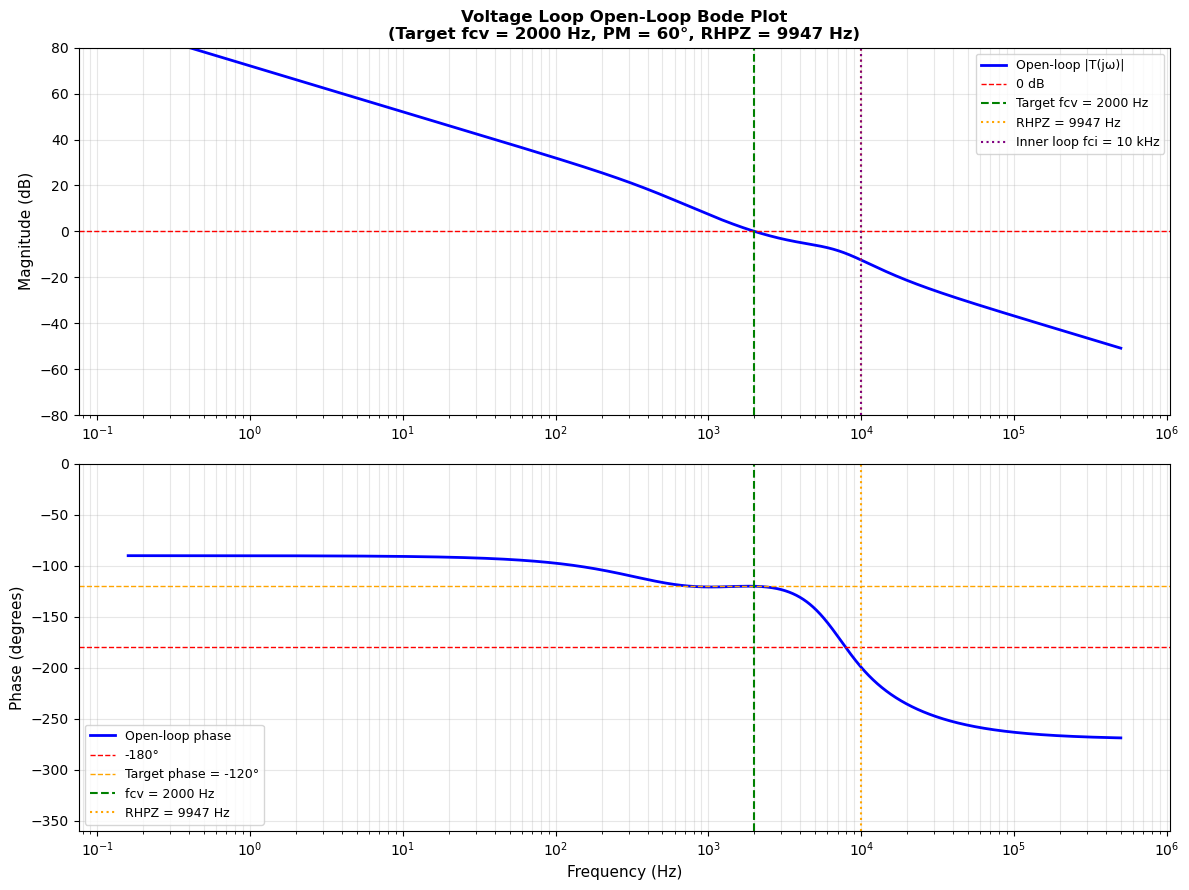

Bode plot generated.


In [27]:
# Frequency sweep: 1 Hz to 500 kHz (angular frequency)
w = np.logspace(0, np.log10(2 * np.pi * 500e3), 3000)

# Compute frequency response using control.bode
mag_v, phase_v_rad, _ = control.bode(T_open_v, w, dB=False, deg=False, plot=False)
mag_v_dB    = 20 * np.log10(mag_v)
phase_v_deg = np.degrees(np.unwrap(phase_v_rad))   # unwrap for continuity past -180°
f_hz = w / (2 * np.pi)

# ── Bode Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# Magnitude
ax1.semilogx(f_hz, mag_v_dB, 'b-', linewidth=2, label='Open-loop |T(jω)|')
ax1.axhline(0, color='r', linestyle='--', linewidth=1, label='0 dB')
ax1.axvline(fcv,    color='g',      linestyle='--', linewidth=1.5, label=f'Target fcv = {fcv:.0f} Hz')
ax1.axvline(f_RHPZ, color='orange', linestyle=':',  linewidth=1.5, label=f'RHPZ = {f_RHPZ:.0f} Hz')
ax1.axvline(fci,    color='purple', linestyle=':',  linewidth=1.5, label=f'Inner loop fci = {fci/1e3:.0f} kHz')
ax1.set_ylabel('Magnitude (dB)', fontsize=11)
ax1.set_title(
    f'Voltage Loop Open-Loop Bode Plot\n'
    f'(Target fcv = {fcv:.0f} Hz, PM = {phi_mv}°, RHPZ = {f_RHPZ:.0f} Hz)',
    fontsize=12, fontweight='bold'
)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim([-80, 80])
ax1.grid(True, which='both', alpha=0.3)

# Phase
ax2.semilogx(f_hz, phase_v_deg, 'b-', linewidth=2, label='Open-loop phase')
ax2.axhline(-180,          color='r',      linestyle='--', linewidth=1,   label='-180°')
ax2.axhline(-180 + phi_mv, color='orange', linestyle='--', linewidth=1,   label=f'Target phase = {-180+phi_mv:.0f}°')
ax2.axvline(fcv,           color='g',      linestyle='--', linewidth=1.5, label=f'fcv = {fcv:.0f} Hz')
ax2.axvline(f_RHPZ,        color='orange', linestyle=':',  linewidth=1.5, label=f'RHPZ = {f_RHPZ:.0f} Hz')
ax2.set_xlabel('Frequency (Hz)', fontsize=11)
ax2.set_ylabel('Phase (degrees)', fontsize=11)
ax2.set_ylim([-360, 0])
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()
print("Bode plot generated.")

### 3.7 Verify Crossover Frequency and Phase Margin

In [28]:
# Stability margins via control.margin
gm_v, pm_v, _, wgc_v = control.margin(T_open_v)   # wgc_v = 0-dB crossover (rad/s)

fcv_actual = wgc_v / (2 * np.pi)
PM_actual  = pm_v
GM_db      = 20 * np.log10(gm_v) if np.isfinite(gm_v) else float('inf')

# Phase at crossover (from bode data of previous cell)
idx_0db      = np.argmin(np.abs(mag_v_dB))
phase_at_0db = phase_v_deg[idx_0db]

print("=" * 58)
print("OPEN-LOOP PERFORMANCE VERIFICATION")
print("=" * 58)
print(f"  Target crossover frequency:  {fcv:.1f} Hz")
print(f"  Actual crossover frequency:  {fcv_actual:.1f} Hz")
print(f"  Frequency error:             {(fcv_actual - fcv)*100/fcv:.2f}%")
print()
print(f"  Target phase margin:         {phi_mv:.1f}°")
print(f"  Actual phase margin:         {PM_actual:.2f}°")
print(f"  Phase margin error:          {PM_actual - phi_mv:.2f}°")
print()
print(f"  Gain margin:                 {GM_db:.2f} dB")
print()
print(f"  RHPZ frequency:              {f_RHPZ:.1f} Hz")
print(f"  fcv / f_RHPZ ratio:          {fcv_actual/f_RHPZ*100:.1f}%  (safe < 33%)")

OPEN-LOOP PERFORMANCE VERIFICATION
  Target crossover frequency:  2000.0 Hz
  Actual crossover frequency:  2000.0 Hz
  Frequency error:             0.00%

  Target phase margin:         60.0°
  Actual phase margin:         60.00°
  Phase margin error:          0.00°

  Gain margin:                 9.59 dB

  RHPZ frequency:              9947.2 Hz
  fcv / f_RHPZ ratio:          20.1%  (safe < 33%)


### 3.8 Closed-Loop Step Response (Output Voltage)

In [34]:

# Closed-loop via control.feedback: T_cl_v = T_open_v / (1 + T_open_v)
T_cl_v = control.feedback(T_open_v, 1)

# Step response
t_v, y_v = control.step_response(T_cl_v)
y_v = np.squeeze(y_v)

# ── Rise time (10% → 90%) ─────────────────────────────────────────
trace_10 = np.where(y_v >= 0.1)[0]
trace_90 = np.where(y_v >= 0.9)[0]
rise_time_v = (t_v[trace_90[0]] - t_v[trace_10[0]]) \
              if (len(trace_10) > 0 and len(trace_90) > 0) else t_v[-1]

# ── Settling time (±2%): last time the response leaves the band ───
# Find the last index where response is OUTSIDE [0.98, 1.02]
outside_idx = np.where((y_v < 0.98) | (y_v > 1.02))[0]
if len(outside_idx) > 0:
    last_out = outside_idx[-1]
    settle_time_v = t_v[last_out + 1] if last_out + 1 < len(t_v) else t_v[-1]
else:
    settle_time_v = t_v[0]   # already settled at t=0

# ── Overshoot ─────────────────────────────────────────────────────
overshoot_v = (np.max(y_v) - 1.0) * 100 if np.max(y_v) > 1.0 else 0.0

print("=" * 58)
print("CLOSED-LOOP STEP RESPONSE METRICS")
print("=" * 58)
print(f"  Rise time (10%-90%):    {rise_time_v*1e3:.3f} ms  ({rise_time_v:.3e} s)")
print(f"  Settling time (±2%):    {settle_time_v*1e3:.3f} ms  ({settle_time_v:.3e} s)")
print(f"  Overshoot:              {overshoot_v:.2f}%")
print(f"  Peak value:             {np.max(y_v):.4f}")
print(f"  Steady-state error:     {(y_v[-1] - 1.0)*100:.4f}%")


CLOSED-LOOP STEP RESPONSE METRICS
  Rise time (10%-90%):    0.066 ms  (6.588e-05 s)
  Settling time (±2%):    0.539 ms  (5.390e-04 s)
  Overshoot:              13.30%
  Peak value:             1.1330
  Steady-state error:     -0.0000%


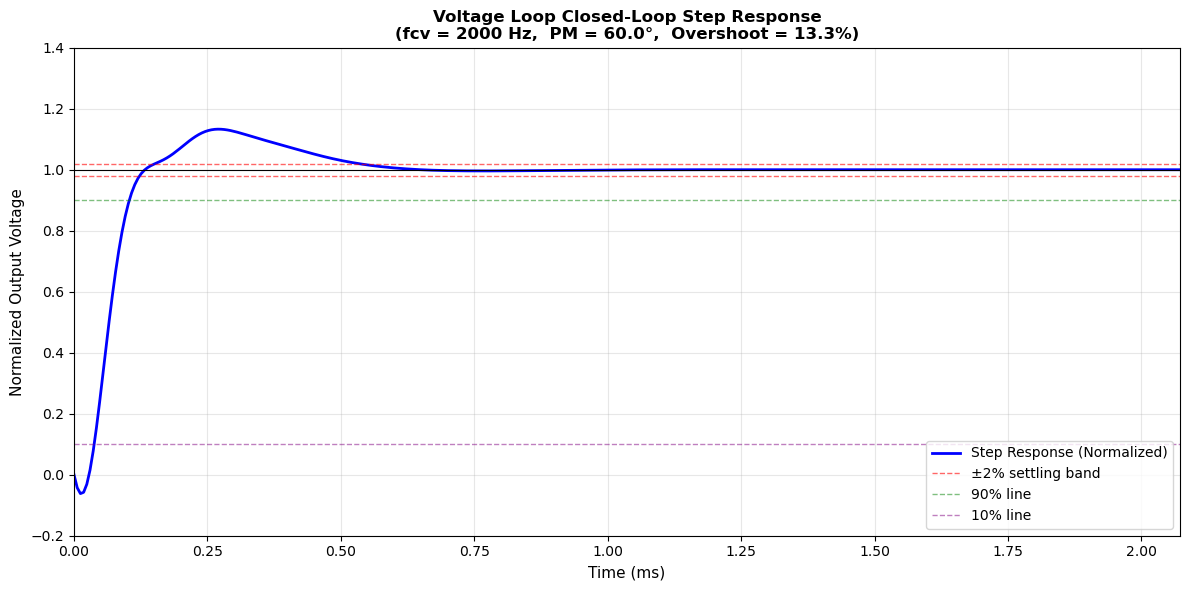

Step response plot generated.


In [30]:
# Plot closed-loop step response
fig, ax = plt.subplots(figsize=(12, 6))

t_ms = t_v * 1e3    # convert to milliseconds
ax.plot(t_ms, y_v, 'b-', linewidth=2, label='Step Response (Normalized)')
ax.axhline(1.0,  color='k',      linestyle='-',  linewidth=0.8)
ax.axhline(0.98, color='r',      linestyle='--', linewidth=1, alpha=0.6, label='±2% settling band')
ax.axhline(1.02, color='r',      linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(0.9,  color='green',  linestyle='--', linewidth=1, alpha=0.5, label='90% line')
ax.axhline(0.1,  color='purple', linestyle='--', linewidth=1, alpha=0.5, label='10% line')

ax.grid(True, alpha=0.3)
ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Normalized Output Voltage', fontsize=11)
ax.set_title(
    f'Voltage Loop Closed-Loop Step Response\n'
    f'(fcv = {fcv_actual:.0f} Hz,  PM = {PM_actual:.1f}°,  Overshoot = {overshoot_v:.1f}%)',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right')
ax.set_xlim([0, np.max(t_ms)])
ax.set_ylim([-0.2, 1.4])

plt.tight_layout()
plt.show()
print("Step response plot generated.")

## Part 4: Design Summary and Implementation

### 4.1 Final Results

In [31]:
print("\n" + "=" * 60)
print("DESIGN SUMMARY — VOLTAGE LOOP PI CONTROLLER")
print("=" * 60)
print()
print("Circuit and Operating Point:")
print(f"  Vin={Vin} V,  Vo={Vo} V,  L={L*1e6:.0f} µH,  C={C*1e6:.0f} µF,  R={R} Ω")
print(f"  D = {D:.4f}  ({D*100:.1f}%),   I_L = {IL_ss:.4f} A")
print()
print("Key Frequency Constraints:")
print(f"  Inner loop bandwidth fci  = {fci/1e3:.1f} kHz")
print(f"  RHPZ frequency            = {f_RHPZ:.1f} Hz  ({f_RHPZ/1e3:.2f} kHz)")
print(f"  Selected fcv              = {fcv:.1f} Hz   (= {fcv/fci*100:.1f}% of fci, {fcv/f_RHPZ*100:.1f}% of RHPZ)")
print()
print("Voltage Loop PI Parameters:")
print(f"  Proportional gain  Kpv  = {Kpv:.10g}")
print(f"  Integral gain      Kiv  = {Kiv:.10g}")
print(f"  Controller zero    fz   = {fz_v:.2f} Hz")
print()
print("Continuous-Time Transfer Function:")
print(f"  Gpiv(s) = {Kpv:.6g} + {Kiv:.6g}/s")
print()
print("Verified Performance:")
print(f"  Actual crossover frequency fcv = {fcv_actual:.1f} Hz")
print(f"  Actual phase margin PM         = {PM_actual:.2f}°")
print(f"  Gain margin                    = {GM_db:.2f} dB")
print(f"  Rise time (10%-90%)            = {rise_time_v*1e3:.2f} ms")
print(f"  Settling time (±2%)            = {settle_time_v*1e3:.2f} ms")
print(f"  Overshoot                      = {overshoot_v:.2f}%")
print()

# Discrete-time conversion using control.c2d (Tustin / bilinear)
Ts        = 1 / fsw
Gpiv_d    = control.c2d(Gpiv, Ts, method='tustin')
c2d_num_v = np.array(Gpiv_d.num).flatten()
c2d_den_v = np.array(Gpiv_d.den).flatten()

print("Discrete-Time Implementation (Tustin, Ts = 1/fsw):")
print(f"  Z-domain numerator:   {c2d_num_v}")
print(f"  Z-domain denominator: {c2d_den_v}")
print(f"  v_ref[n] = v_ref[n-1] + c0*e[n] + c1*e[n-1]")
print(f"    c0 = {c2d_num_v[0]:.10g}")
print(f"    c1 = {c2d_num_v[1]:.10g}")


DESIGN SUMMARY — VOLTAGE LOOP PI CONTROLLER

Circuit and Operating Point:
  Vin=12 V,  Vo=24 V,  L=24 µH,  C=100 µF,  R=6 Ω
  D = 0.5000  (50.0%),   I_L = 8.0000 A

Key Frequency Constraints:
  Inner loop bandwidth fci  = 10.0 kHz
  RHPZ frequency            = 9947.2 Hz  (9.95 kHz)
  Selected fcv              = 2000.0 Hz   (= 20.0% of fci, 20.1% of RHPZ)

Voltage Loop PI Parameters:
  Proportional gain  Kpv  = 2.08978774
  Integral gain      Kiv  = 16882.2293
  Controller zero    fz   = 1285.72 Hz

Continuous-Time Transfer Function:
  Gpiv(s) = 2.08979 + 16882.2/s

Verified Performance:
  Actual crossover frequency fcv = 2000.0 Hz
  Actual phase margin PM         = 60.00°
  Gain margin                    = 9.59 dB
  Rise time (10%-90%)            = 0.07 ms
  Settling time (±2%)            = 0.13 ms
  Overshoot                      = 13.30%

Discrete-Time Implementation (Tustin, Ts = 1/fsw):
  Z-domain numerator:   [ 2.17419889 -2.00537659]
  Z-domain denominator: [ 1. -1.]
  v_ref[n] 

### 4.2 Implementation Recommendations

In [32]:
print("=" * 60)
print("IMPLEMENTATION RECOMMENDATIONS")
print("=" * 60)
print()
print("1. BANDWIDTH SAFETY MARGINS:")
print(f"   fcv ({fcv:.0f} Hz) << fci ({fci/1e3:.0f} kHz) : ratio = 1:{fci/fcv:.0f}  ✓")
print(f"   fcv ({fcv:.0f} Hz) << RHPZ ({f_RHPZ:.0f} Hz) : ratio = 1:{f_RHPZ/fcv:.1f}  ✓")
print()
print("2. ANTI-WINDUP:")
print(f"   Voltage reference saturation limits: [{Vo*0.5:.1f}, {Vo*1.2:.1f}] V")
print("   Use back-calculation anti-windup (recommended)")
print()
print("3. INNER/OUTER LOOP INTERACTION:")
print("   The outer loop output is the inner loop's current reference.")
print(f"   Clamp the current reference to a safe level (suggested: ±{IL_ss*3:.1f} A)")
print()
print("4. RHPZ ROBUSTNESS NOTE:")
print(f"   At full load R={R} Ω, RHPZ = {f_RHPZ:.0f} Hz.")
print("   At lighter loads (higher R), RHPZ shifts higher → more margin.")
print("   At heavier loads (lower R), RHPZ shifts lower → verify stability!")
print()
print("5. TUNING PROCEDURE (Hardware):")
print("   • Start at 70% of calculated Kpv")
print("   • Observe voltage step response; increase Kpv for faster response")
print("   • Add Kiv to eliminate steady-state error")
print("   • Monitor phase margin with a network analyzer")

IMPLEMENTATION RECOMMENDATIONS

1. BANDWIDTH SAFETY MARGINS:
   fcv (2000 Hz) << fci (10 kHz) : ratio = 1:5  ✓
   fcv (2000 Hz) << RHPZ (9947 Hz) : ratio = 1:5.0  ✓

2. ANTI-WINDUP:
   Voltage reference saturation limits: [12.0, 28.8] V
   Use back-calculation anti-windup (recommended)

3. INNER/OUTER LOOP INTERACTION:
   The outer loop output is the inner loop's current reference.
   Clamp the current reference to a safe level (suggested: ±24.0 A)

4. RHPZ ROBUSTNESS NOTE:
   At full load R=6 Ω, RHPZ = 9947 Hz.
   At lighter loads (higher R), RHPZ shifts higher → more margin.
   At heavier loads (lower R), RHPZ shifts lower → verify stability!

5. TUNING PROCEDURE (Hardware):
   • Start at 70% of calculated Kpv
   • Observe voltage step response; increase Kpv for faster response
   • Add Kiv to eliminate steady-state error
   • Monitor phase margin with a network analyzer


## Appendix: Mathematical References

### Plant Transfer Functions Summary

**Inner Loop Equivalent (First-Order Approx.):**
$$G_{id\_close}(s) \approx \frac{1}{H_i} \cdot \frac{1}{1 + s/\omega_{ci}}$$

**$G_{vi}(s)$ — Power Stage (Inductor Current → Output Voltage):**
$$G_{vi}(s) = \frac{R(1-D)}{2} \cdot \frac{1 - s\dfrac{L}{R(1-D)^2}}{1 + s\dfrac{RC}{2}}$$

| Feature | Location | Effect |
|---------|----------|--------|
| DC gain | $K_{dc} = R(1-D)/2$ | Load-dependent |
| Output pole | $\omega_p = 2/(RC)$ | −20 dB/dec roll-off |
| **RHPZ** | $\omega_{rhpz} = R(1-D)^2/L$ | −90° phase, +20 dB/dec magnitude |

### PI Controller Phase Contribution

At frequency $\omega$, the PI controller $G_{piv}(s) = K_{pv} + K_{iv}/s$ contributes:

$$\angle G_{piv}(j\omega) = \arctan\!\left(\frac{-K_{iv}/\omega}{K_{pv}}\right) = \arctan\!\left(\frac{-\omega_z}{\omega}\right)$$

where $\omega_z = K_{iv}/K_{pv}$ is the PI zero. At crossover $\omega = \omega_{cv}$, this phase exactly equals $\phi_{req,v}$ by design.